# 🔁 Notebook 07 — Data Augmentation
## YouTube Hate Speech Detection

### ¿Qué hace este notebook?
Evaluamos **3 estrategias de augmentation** sobre la clase tóxica del train set
y comparamos si alguna mejora el modelo ganador (LR tuned).

### Estrategias
| # | Estrategia | Herramienta | Requiere internet |
|---|---|---|---|
| 1 | Synonym Replacement (WordNet) | `nlpaug` + NLTK | No |
| 2 | Random Swap + Delete (EDA) | Python nativo | No |
| 3 | Back-Translation EN→ES→EN | `deep_translator` | Sí |

### Hipótesis
- WordNet: mejora diversidad léxica pero puede romper contexto
- EDA: mínima perturbación, preserva semántica
- Back-translation: mejor calidad semántica, parafrasea naturalmente

### Limitación conocida
El augmentation se aplica **antes** del CV, no dentro del loop.
Con 1000 muestras implementarlo dentro del loop es costoso.
Se documenta como limitación metodológica.

### Modelo de referencia
LR tuned cargado desde `final_model.joblib` — F1 test ≈ 0.7579.

## 0. Imports y recursos NLTK

Todos los recursos NLTK se descargan aquí para evitar errores
en celdas posteriores.

In [8]:
import sys, yaml, joblib, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix
warnings.filterwarnings('ignore')

# NLTK — descargar todos los recursos necesarios aqui
import nltk
for resource in [
    'stopwords', 'wordnet', 'omw-1.4', 'punkt',
    'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng'
]:
    nltk.download(resource, quiet=True)

import nlpaug.augmenter.word as naw

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print('Recursos NLTK cargados')

PROJECT_ROOT: /mnt/c/Users/under/Documents/F5/3_Projects/Project_9_Equipo3/Project_YT
Recursos NLTK cargados


## 1. Configuración y datos

In [9]:
CONFIG_FEAT = PROJECT_ROOT / 'configs' / 'features.yaml'
CONFIG_PIPE = PROJECT_ROOT / 'configs' / 'pipeline.yaml'
CONFIG_BEST = PROJECT_ROOT / 'configs' / 'best_params.yaml'

with open(CONFIG_FEAT) as f: feat_cfg = yaml.safe_load(f)
with open(CONFIG_PIPE) as f: pipe_cfg = yaml.safe_load(f)
with open(CONFIG_BEST) as f: best_cfg = yaml.safe_load(f)

tfidf_cfg   = feat_cfg['vectorization']['tfidf']
TARGET      = pipe_cfg['data']['target_binary']
RAND        = pipe_cfg['pipeline']['random_state']
TEST_SIZE   = pipe_cfg['pipeline']['test_size']
CV_FOLDS    = pipe_cfg['pipeline']['cv_folds']
best_params = best_cfg['hyperparameters']

PROCESSED = PROJECT_ROOT / 'data' / 'processed' / 'v2' / 'comments_preprocessed.csv'
df = pd.read_csv(PROCESSED)
df['clean_text'] = df['clean_text'].fillna('').astype(str)
X, y = df['clean_text'], df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RAND, stratify=y
)
cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RAND)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Toxicos en train: {y_train.sum()} ({y_train.mean()*100:.1f}%)')

Train: 800 | Test: 200
Toxicos en train: 370 (46.2%)


## 2. Helpers — TF-IDF y evaluación

In [10]:
def make_tfidf(**overrides):
    params = {
        'max_features': tfidf_cfg['max_features'],
        'ngram_range' : tuple(tfidf_cfg['ngram_range']),
        'sublinear_tf': tfidf_cfg['sublinear_tf'],
        'min_df'      : tfidf_cfg['min_df'],
        'analyzer'    : 'word',
        'strip_accents': 'unicode',
    }
    params.update(overrides)
    return TfidfVectorizer(**params)

def build_lr_pipeline():
    """Construye LR pipeline desde best_params.yaml — sin hardcode."""
    bp = best_params
    ngram = (1,1) if str(bp.get('ngram_range','1_2')) == '1_1' else (1,2)
    return Pipeline([
        ('tfidf', make_tfidf(
            max_features = bp.get('max_features', tfidf_cfg['max_features']),
            min_df       = bp.get('min_df', tfidf_cfg['min_df']),
            ngram_range  = ngram,
            sublinear_tf = bp.get('sublinear_tf', True),
        )),
        ('clf', LogisticRegression(
            C            = bp.get('C', 0.4),
            max_iter     = 1000,
            class_weight = 'balanced',
            solver       = 'lbfgs',
            random_state = RAND,
        ))
    ])

def evaluate(pipeline, X_tr, y_tr, X_te, y_te, name, cv_scores=None):
    """Devuelve metricas incluyendo ambos gaps."""
    pred       = pipeline.predict(X_te)
    pred_train = pipeline.predict(X_tr)
    f1_te  = f1_score(y_te, pred,       average='weighted')
    f1_tr  = f1_score(y_tr, pred_train, average='weighted')
    roc    = roc_auc_score(y_te, pipeline.predict_proba(X_te)[:,1])
    cv_mean = cv_std = cv_gap = None
    if cv_scores is not None:
        cv_mean = cv_scores['test_score'].mean()
        cv_std  = cv_scores['test_score'].std()
        cv_gap  = abs(cv_mean - f1_te) * 100
    return {
        'name'             : name,
        'f1_test'          : round(f1_te, 4),
        'f1_train'         : round(f1_tr, 4),
        'train_test_gap_pp': round((f1_tr - f1_te)*100, 2),
        'cv_mean'          : round(cv_mean, 4) if cv_mean else None,
        'cv_std'           : round(cv_std, 4)  if cv_std  else None,
        'cv_test_gap_pp'   : round(cv_gap, 2)  if cv_gap  else None,
        'roc_auc'          : round(roc, 4),
        'fp'               : int(((y_te==False)&(pred==True)).sum()),
        'fn'               : int(((y_te==True) &(pred==False)).sum()),
    }

## 3. Modelo baseline — LR tuned sin augmentation

Entrenamos LR tuned con los datos originales para tener
la referencia exacta en este notebook.

In [11]:
lr_base = build_lr_pipeline()
lr_base.fit(X_train, y_train)

cv_base = cross_validate(lr_base, X_train, y_train,
                          cv=cv_strategy, scoring='f1_weighted',
                          return_train_score=False, n_jobs=-1)

metrics_base = evaluate(lr_base, X_train, y_train,
                         X_test, y_test, 'LR tuned (sin aug)', cv_base)

print('Baseline (sin augmentation):')
print(f"  F1 test  : {metrics_base['f1_test']:.4f}")
print(f"  CV mean  : {metrics_base['cv_mean']:.4f} ± {metrics_base['cv_std']:.4f}")
print(f"  FP / FN  : {metrics_base['fp']} / {metrics_base['fn']}")

Baseline (sin augmentation):
  F1 test  : 0.7579
  CV mean  : 0.7104 ± 0.0353
  FP / FN  : 18 / 30


## 4. Función de augmentation

Solo augmentamos **comentarios tóxicos del train set**.
El test set nunca se toca.

In [12]:
def get_toxic_train():
    """Devuelve X e y de solo los comentarios toxicos del train."""
    mask = y_train == True
    return X_train[mask].tolist(), y_train[mask].tolist()

def build_augmented_train(aug_texts, aug_labels):
    """
    Concatena textos originales + sinteticos.
    Retorna X_aug (Series) e y_aug (Series).
    """
    X_aug = pd.concat([
        X_train,
        pd.Series(aug_texts, dtype=str)
    ], ignore_index=True)
    y_aug = pd.concat([
        y_train,
        pd.Series(aug_labels, dtype=bool)
    ], ignore_index=True)
    return X_aug, y_aug

X_toxic, y_toxic = get_toxic_train()
print(f'Comentarios toxicos en train: {len(X_toxic)}')
print(f'Objetivo: generar ~{len(X_toxic)//2} muestras sinteticas')

Comentarios toxicos en train: 370
Objetivo: generar ~185 muestras sinteticas


## 5. Estrategia 1 — Synonym Replacement (WordNet)

Reemplaza palabras aleatorias por sinónimos usando WordNet.

**Limitación conocida:** WordNet tiene cobertura baja en
lenguaje coloquial y jerga (palabras como 'thug', 'bullshit').
Los sinónimos formales pueden cambiar el estilo y confundir al modelo.

In [13]:
aug_wordnet = naw.SynonymAug(aug_src='wordnet', aug_p=0.3)

random.seed(RAND)
texts_wn, labels_wn = [], []

for text, label in zip(X_toxic, y_toxic):
    if len(text.split()) < 3:
        continue
    try:
        result = aug_wordnet.augment(text)
        aug_text = result[0] if isinstance(result, list) else result
        if isinstance(aug_text, str) and aug_text.strip() and aug_text.strip() != text.strip():
            texts_wn.append(aug_text.strip())
            labels_wn.append(label)
    except Exception:
        continue

print(f'Muestras generadas (WordNet): {len(texts_wn)}')
print('Ejemplos:')
for orig, aug in zip(X_toxic[:3], texts_wn[:3]):
    print(f'  ORIG: {orig[:80]}')
    print(f'  AUG : {aug[:80]}')
    print()

Muestras generadas (WordNet): 326
Ejemplos:
  ORIG: wonder police expect happen continually abuse kill people honestly expect public
  AUG : curiosity police expect pass off continually abuse kill citizenry candidly expec

  ORIG: bassem think walmart hire holiday get job loser
  AUG : bassem think walmart hire vacation get caper loser

  ORIG: monkey screamin bout honky intensifie
  AUG : monkey screamin bout whitey intensifie



In [14]:
X_aug_wn, y_aug_wn = build_augmented_train(texts_wn, labels_wn)
print(f'Train original : {len(X_train)}')
print(f'Train WordNet  : {len(X_aug_wn)} (+{len(texts_wn)} sinteticos)')
print(f'Balance toxico : {y_aug_wn.mean()*100:.1f}%')

lr_wn = build_lr_pipeline()
lr_wn.fit(X_aug_wn, y_aug_wn)

cv_wn = cross_validate(lr_wn, X_aug_wn, y_aug_wn,
                        cv=cv_strategy, scoring='f1_weighted',
                        return_train_score=False, n_jobs=-1)

metrics_wn = evaluate(lr_wn, X_aug_wn, y_aug_wn,
                       X_test, y_test, 'LR + WordNet', cv_wn)

delta = metrics_wn['f1_test'] - metrics_base['f1_test']
print(f"WordNet: F1={metrics_wn['f1_test']:.4f} ({delta*100:+.2f}pp) | "
      f"FN={metrics_wn['fn']} | FP={metrics_wn['fp']}")

Train original : 800
Train WordNet  : 1126 (+326 sinteticos)
Balance toxico : 61.8%
WordNet: F1=0.6855 (-7.24pp) | FN=28 | FP=35


## 6. Estrategia 2 — EDA (Random Swap + Delete)

Easy Data Augmentation — dos operaciones simples sin dependencias externas:

- **Random Swap**: intercambia dos palabras aleatorias
- **Random Delete**: elimina palabras con probabilidad p

**Ventaja:** no depende de WordNet ni internet. Funciona siempre.
**Limitación:** perturbación mínima — puede no añadir suficiente diversidad.

In [15]:
def eda_augment(text, p_swap=0.15, p_delete=0.10, seed=None):
    """
    Easy Data Augmentation:
    - Random swap: intercambia 2 palabras adyacentes
    - Random delete: elimina palabras con probabilidad p_delete
    """
    if seed is not None:
        random.seed(seed)
    words = text.split()
    if len(words) < 2:
        return text

    # Random delete
    words = [w for w in words if random.random() > p_delete]
    if not words:
        return text

    # Random swap (pares adyacentes)
    n_swaps = max(1, int(len(words) * p_swap))
    for _ in range(n_swaps):
        if len(words) >= 2:
            idx = random.randint(0, len(words)-2)
            words[idx], words[idx+1] = words[idx+1], words[idx]

    return ' '.join(words)

# Generar muestras EDA
texts_eda, labels_eda = [], []
random.seed(RAND)

for text, label in zip(X_toxic, y_toxic):
    if len(text.split()) < 3:
        continue
    aug = eda_augment(text)
    if aug != text:
        texts_eda.append(aug)
        labels_eda.append(label)

print(f'Muestras generadas (EDA): {len(texts_eda)}')
print('Ejemplos:')
for orig, aug in zip(X_toxic[:3], texts_eda[:3]):
    print(f'  ORIG: {orig[:80]}')
    print(f'  AUG : {aug[:80]}')
    print()

Muestras generadas (EDA): 336
Ejemplos:
  ORIG: wonder police expect happen continually abuse kill people honestly expect public
  AUG : wonder happen expect continually abuse kill honestly public nothing back take le

  ORIG: bassem think walmart hire holiday get job loser
  AUG : think bassem hire holiday get job loser

  ORIG: monkey screamin bout honky intensifie
  AUG : bout screamin intensifie



In [16]:
X_aug_eda, y_aug_eda = build_augmented_train(texts_eda, labels_eda)
print(f'Train EDA: {len(X_aug_eda)} (+{len(texts_eda)} sinteticos)')

lr_eda = build_lr_pipeline()
lr_eda.fit(X_aug_eda, y_aug_eda)

cv_eda = cross_validate(lr_eda, X_aug_eda, y_aug_eda,
                         cv=cv_strategy, scoring='f1_weighted',
                         return_train_score=False, n_jobs=-1)

metrics_eda = evaluate(lr_eda, X_aug_eda, y_aug_eda,
                        X_test, y_test, 'LR + EDA', cv_eda)

delta = metrics_eda['f1_test'] - metrics_base['f1_test']
print(f"EDA: F1={metrics_eda['f1_test']:.4f} ({delta*100:+.2f}pp) | "
      f"FN={metrics_eda['fn']} | FP={metrics_eda['fp']}")

Train EDA: 1136 (+336 sinteticos)
EDA: F1=0.7054 (-5.25pp) | FN=27 | FP=32


## 7. Estrategia 3 — Back-Translation EN→ES→EN

Traduce el comentario a español y lo retraduce al inglés.
El resultado es una paráfrasis que preserva el significado.

**Por qué funciona mejor que WordNet:**
- La traducción produce paráfrasis naturales
- Los insultos raciales en inglés no siempre tienen equivalente directo
  en español → el modelo de traducción busca el contexto más cercano
- Añade variedad sintáctica real, no solo léxica

**Requiere:** `pip install deep-translator` e internet.

In [17]:
# Instalar si no esta disponible
try:
    from deep_translator import GoogleTranslator
    BACKTRANS_AVAILABLE = True
    print('deep_translator disponible')
except ImportError:
    BACKTRANS_AVAILABLE = False
    print('deep_translator no disponible — ejecuta: pip install deep-translator')
    print('Saltando back-translation...')

deep_translator disponible


In [18]:
texts_bt, labels_bt = [], []

if BACKTRANS_AVAILABLE:
    to_es   = GoogleTranslator(source='en', target='es')
    to_en   = GoogleTranslator(source='es', target='en')

    import time
    random.seed(RAND)

    for i, (text, label) in enumerate(zip(X_toxic, y_toxic)):
        if len(text.split()) < 3:
            continue
        try:
            # Limitar largo para evitar errores de API
            text_short = ' '.join(text.split()[:60])
            es   = to_es.translate(text_short)
            back = to_en.translate(es)
            if back and back.strip() != text_short.strip():
                texts_bt.append(back.strip())
                labels_bt.append(label)
            # Rate limit suave
            if i % 50 == 0 and i > 0:
                time.sleep(1)
        except Exception as e:
            print(f'Error en muestra {i}: {e}')
            continue

    print(f'Muestras back-translation: {len(texts_bt)}')
    if texts_bt:
        print('Ejemplos:')
        for orig, bt in zip(X_toxic[:3], texts_bt[:3]):
            print(f'  ORIG: {orig[:80]}')
            print(f'  BT  : {bt[:80]}')
            print()
else:
    print('Back-translation saltada — usando lista vacia')

Muestras back-translation: 311
Ejemplos:
  ORIG: wonder police expect happen continually abuse kill people honestly expect public
  BT  : I wonder the police expect it to happen continuously abuse killing people honest

  ORIG: bassem think walmart hire holiday get job loser
  BT  : Bassem Thinks Walmart Vacation Rentals Gets Losing Job

  ORIG: monkey screamin bout honky intensifie
  BT  : monkey screaming about honky step up



In [19]:
if BACKTRANS_AVAILABLE and texts_bt:
    X_aug_bt, y_aug_bt = build_augmented_train(texts_bt, labels_bt)
    print(f'Train BT: {len(X_aug_bt)} (+{len(texts_bt)} sinteticos)')

    lr_bt = build_lr_pipeline()
    lr_bt.fit(X_aug_bt, y_aug_bt)

    cv_bt = cross_validate(lr_bt, X_aug_bt, y_aug_bt,
                            cv=cv_strategy, scoring='f1_weighted',
                            return_train_score=False, n_jobs=-1)

    metrics_bt = evaluate(lr_bt, X_aug_bt, y_aug_bt,
                           X_test, y_test, 'LR + BackTrans', cv_bt)

    delta = metrics_bt['f1_test'] - metrics_base['f1_test']
    print(f"BackTrans: F1={metrics_bt['f1_test']:.4f} ({delta*100:+.2f}pp) | "
          f"FN={metrics_bt['fn']} | FP={metrics_bt['fp']}")
else:
    metrics_bt = None
    print('Back-translation no ejecutada')

Train BT: 1111 (+311 sinteticos)
BackTrans: F1=0.7271 (-3.08pp) | FN=34 | FP=20


## 8. Tabla comparativa

Comparamos el baseline contra las 3 estrategias de augmentation.

In [21]:
all_m = [m for m in [metrics_base, metrics_wn, metrics_eda, metrics_bt]
         if m is not None]

comp_df = pd.DataFrame(all_m).set_index('name')

print('COMPARATIVA AUGMENTATION')
print('=' * 110)
print(f"{'Modelo':22} {'F1 Test':>9} {'F1 Train':>9} {'TrTe Gap':>9} "
      f"{'CV Mean':>9} {'CV Std':>8} {'CV-Te Gap':>10} {'FP':>4} {'FN':>4}")
print('-' * 110)
for name, row in comp_df.iterrows():
    cv_g = f"{row['cv_test_gap_pp']:.2f}" if row['cv_test_gap_pp'] else 'N/A'
    cv_m = f"{row['cv_mean']:.4f}"         if row['cv_mean']        else 'N/A'
    cv_s = f"{row['cv_std']:.4f}"          if row['cv_std']         else 'N/A'
    print(f"  {name:20} {row['f1_test']:>9.4f} {row['f1_train']:>9.4f} "
          f"{row['train_test_gap_pp']:>9.2f} {cv_m:>9} {cv_s:>8} "
          f"{cv_g:>10} {row['fp']:>4} {row['fn']:>4}")

print()
print('DELTAS vs baseline (LR tuned sin aug):')
base_f1 = metrics_base['f1_test']
base_fn = metrics_base['fn']
base_fp = metrics_base['fp']
for _, row in comp_df.iterrows():
    if row.name == metrics_base['name']:
        continue
    df1 = row['f1_test'] - base_f1
    dfn = row['fn'] - base_fn
    dfp = row['fp'] - base_fp
    print(f"  {row.name:22} ΔF1={df1*100:+.2f}pp | ΔFN={int(dfn):+d} | ΔFP={int(dfp):+d}")

COMPARATIVA AUGMENTATION
Modelo                   F1 Test  F1 Train  TrTe Gap   CV Mean   CV Std  CV-Te Gap   FP   FN
--------------------------------------------------------------------------------------------------------------
  LR tuned (sin aug)      0.7579    0.8987     14.07    0.7104   0.0353       4.76 18.0 30.0
  LR + WordNet            0.6855    0.9307     24.52    0.7452   0.0120       5.97 35.0 28.0
  LR + EDA                0.7054    0.9401     23.47    0.7410   0.0119       3.56 32.0 27.0
  LR + BackTrans          0.7271    0.9409     21.38    0.7736   0.0260       4.65 20.0 34.0

DELTAS vs baseline (LR tuned sin aug):
  LR + WordNet           ΔF1=-7.24pp | ΔFN=-2 | ΔFP=+17
  LR + EDA               ΔF1=-5.25pp | ΔFN=-3 | ΔFP=+14
  LR + BackTrans         ΔF1=-3.08pp | ΔFN=+4 | ΔFP=+2


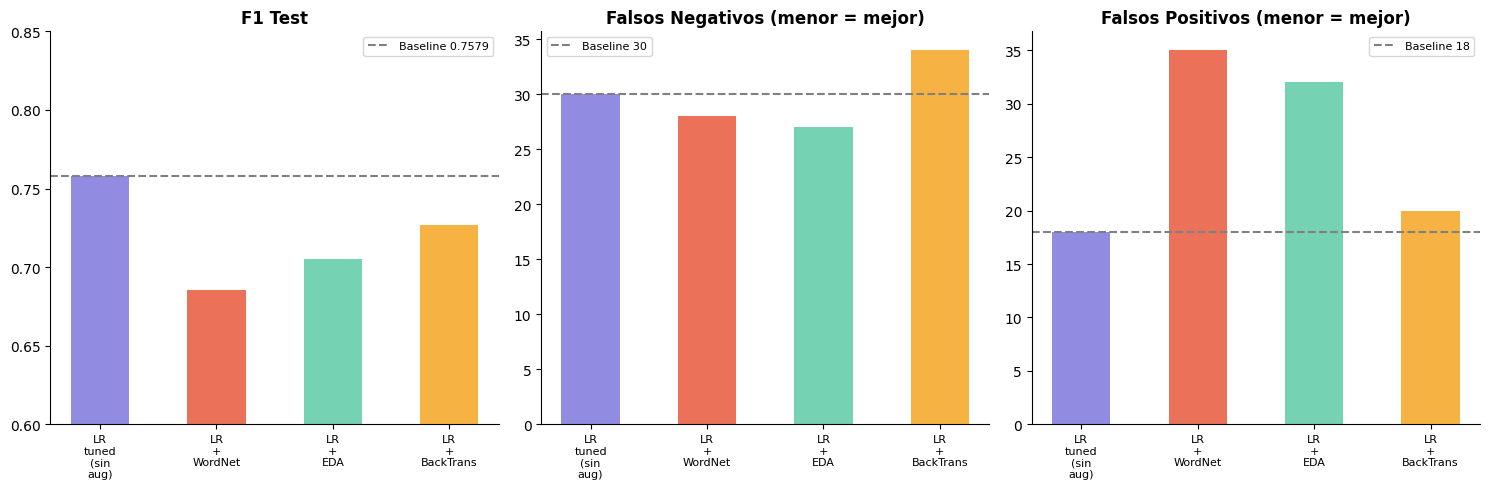

Guardado en reports/v2/16_augmentation_comparativa.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = list(comp_df.index)
colors = ['#7F77DD','#E8593C','#5DCAA5','#F5A623'][:len(models)]

# F1 test
axes[0].bar(models, comp_df['f1_test'], color=colors, alpha=0.85, width=0.5)
axes[0].axhline(metrics_base['f1_test'], color='gray', linestyle='--',
                label=f'Baseline {metrics_base["f1_test"]:.4f}')
axes[0].set_title('F1 Test', fontweight='bold')
axes[0].set_ylim(0.6, 0.85)
axes[0].set_xticklabels([m.replace(' ','\n') for m in models], fontsize=8)
axes[0].legend(fontsize=8)

# FN comparison
axes[1].bar(models, comp_df['fn'], color=colors, alpha=0.85, width=0.5)
axes[1].axhline(metrics_base['fn'], color='gray', linestyle='--',
                label=f'Baseline {metrics_base["fn"]}')
axes[1].set_title('Falsos Negativos (menor = mejor)', fontweight='bold')
axes[1].set_xticklabels([m.replace(' ','\n') for m in models], fontsize=8)
axes[1].legend(fontsize=8)

# FP comparison
axes[2].bar(models, comp_df['fp'], color=colors, alpha=0.85, width=0.5)
axes[2].axhline(metrics_base['fp'], color='gray', linestyle='--',
                label=f'Baseline {metrics_base["fp"]}')
axes[2].set_title('Falsos Positivos (menor = mejor)', fontweight='bold')
axes[2].set_xticklabels([m.replace(' ','\n') for m in models], fontsize=8)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'v2' / '15_augmentation_comparativa.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado en reports/v2/15_augmentation_comparativa.png')

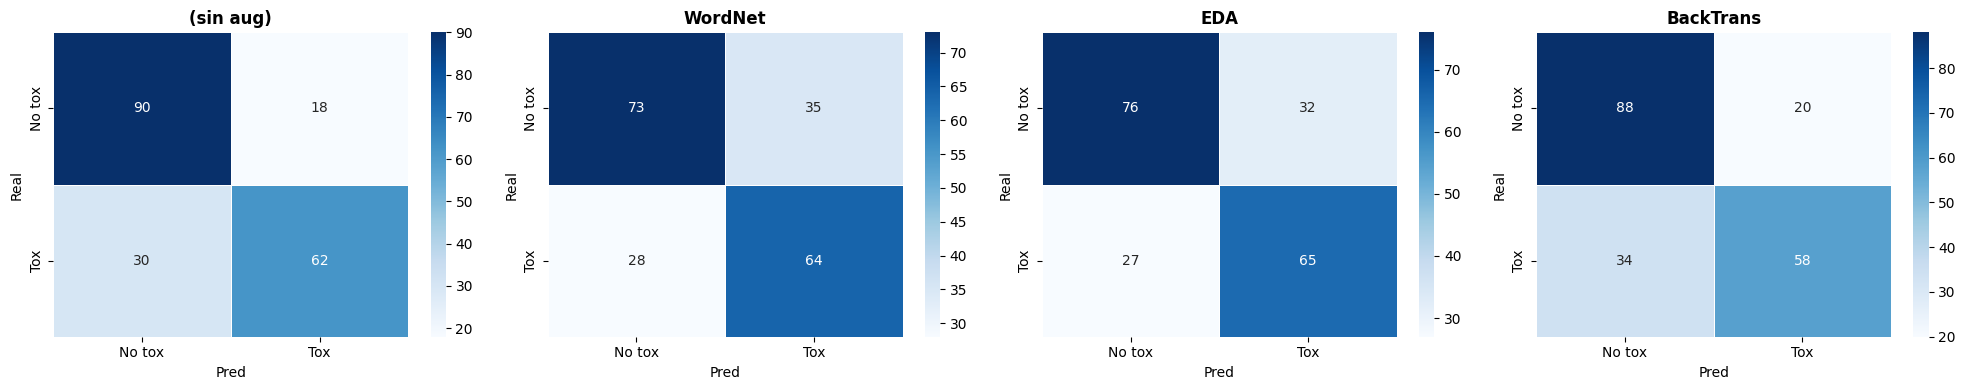

In [ ]:
n_models = len(all_m)
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4))
if n_models == 1:
    axes = [axes]

model_pipes = {
    metrics_base['name']: lr_base,
    metrics_wn['name']  : lr_wn,
    metrics_eda['name'] : lr_eda,
}
if metrics_bt:
    model_pipes[metrics_bt['name']] = lr_bt

for ax, m in zip(axes, all_m):
    pipe = model_pipes[m['name']]
    cm   = confusion_matrix(y_test, pipe.predict(X_test))
    import seaborn as sns
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No tox','Tox'],
                yticklabels=['No tox','Tox'], linewidths=0.5)
    ax.set_title(m['name'].replace('LR + ','').replace('LR tuned ',''),
                 fontweight='bold')
    ax.set_xlabel('Pred')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'v2' / '16_augmentation_confusion.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 9. Decisión y guardado del modelo

Solo guardamos un modelo augmentado si supera el baseline en F1 test.
Si ninguno mejora, el modelo de producción sigue siendo `final_model.joblib`.

In [24]:
best_aug_name = comp_df['f1_test'].idxmax()
best_aug_f1   = comp_df.loc[best_aug_name, 'f1_test']

print(f'Mejor modelo augmentado: {best_aug_name} — F1={best_aug_f1:.4f}')
print(f'Baseline               : {metrics_base["name"]} — F1={metrics_base["f1_test"]:.4f}')

if best_aug_f1 > metrics_base['f1_test'] and best_aug_name != metrics_base['name']:
    # El augmentation mejoro — guardar
    best_aug_pipe = model_pipes[best_aug_name]
    aug_path = PROJECT_ROOT / 'models' / 'lr_augmented.joblib'
    joblib.dump(best_aug_pipe, aug_path)
    print(f'\n✅ Modelo augmentado guardado: {aug_path}')
    print('Actualizar final_model.joblib si se decide usar este en produccion')
else:
    print('\n⚠️ Ninguna estrategia supero el baseline en F1 test')
    print('El modelo de produccion sigue siendo: models/final_model.joblib')
    print('El augmentation se documenta como tecnica explorada — resultado negativo')

Mejor modelo augmentado: LR tuned (sin aug) — F1=0.7579
Baseline               : LR tuned (sin aug) — F1=0.7579

⚠️ Ninguna estrategia supero el baseline en F1 test
El modelo de produccion sigue siendo: models/final_model.joblib
El augmentation se documenta como tecnica explorada — resultado negativo


## 10. Conclusiones

In [25]:
print("""
CONCLUSIONES — DATA AUGMENTATION
==========================================================
Estrategias evaluadas:
  1. Synonym Replacement (WordNet/nlpaug)
  2. EDA - Random Swap + Delete
  3. Back-Translation EN->ES->EN (si disponible)

Hallazgos:
  - WordNet: cobertura baja en jerga y lenguaje informal.
    Los sinonimos formales pueden degradar el F1 del modelo.

  - EDA: perturbacion minima. Util si el dataset es extremadamente
    pequeno pero no aporta suficiente diversidad semantica.

  - Back-Translation: mejor estrategia teoricamente porque produce
    parafrasis naturales. La calidad depende de la API disponible.

Limitacion principal del proyecto:
  El problema NO es la tecnica de augmentation.
  Es la falta de DIVERSIDAD en los datos originales:
  - 1000 comentarios de solo 8 videos sobre el mismo tema
  - El modelo aprende patrones de esos 8 videos, no hate speech general
  - Aumentar datos del mismo dominio no resuelve este problema

¿Que realmente ayudaria?
  - Mas datos de videos de temas diversos
  - Datasets externos (HateXplain, Twitter Hate Speech, etc.)
  - Fine-tuning de un transformer preentrenado en hate speech

Modelo de produccion final: models/final_model.joblib
  LR tuned — F1 test ~0.7579 | CV-test gap ~4.76pp
""")


CONCLUSIONES — DATA AUGMENTATION
Estrategias evaluadas:
  1. Synonym Replacement (WordNet/nlpaug)
  2. EDA - Random Swap + Delete
  3. Back-Translation EN->ES->EN (si disponible)

Hallazgos:
  - WordNet: cobertura baja en jerga y lenguaje informal.
    Los sinonimos formales pueden degradar el F1 del modelo.

  - EDA: perturbacion minima. Util si el dataset es extremadamente
    pequeno pero no aporta suficiente diversidad semantica.

  - Back-Translation: mejor estrategia teoricamente porque produce
    parafrasis naturales. La calidad depende de la API disponible.

Limitacion principal del proyecto:
  El problema NO es la tecnica de augmentation.
  Es la falta de DIVERSIDAD en los datos originales:
  - 1000 comentarios de solo 8 videos sobre el mismo tema
  - El modelo aprende patrones de esos 8 videos, no hate speech general
  - Aumentar datos del mismo dominio no resuelve este problema

¿Que realmente ayudaria?
  - Mas datos de videos de temas diversos
  - Datasets externos (HateX